<a href="https://colab.research.google.com/github/S-r-i-s-h-a/DirtyDatasetSalesAnalytics/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

In [9]:
appl_df = pd.read_csv('/content/drive/MyDrive/ksr_python/Loan Defaulter Datasets/application_data.csv')
print(appl_df.head())
print(appl_df.columns)

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

In [10]:
appl_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
appl_df.dtypes.values

array([dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('int64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('float64'),
       dtype('int64'), dtype('int64'), dtype('float64'), dtype('int64'),
       dtype('float64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'),
       dtype('float64'), dtype('int64'), dtype('int64'), dtype('O'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
 

In [12]:
feature_inventory = pd.DataFrame({
    'feature':appl_df.columns,
    'dtypes': appl_df.dtypes.values,
    'missing_pct': appl_df.isnull().mean().round(2)*100,
    'nunique': appl_df.nunique()
})

In [13]:
feature_inventory

,feature,dtypes,missing_pct,nunique
SK_ID_CURR,SK_ID_CURR,int64,0.0,307511
TARGET,TARGET,int64,0.0,2
NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,object,0.0,2
CODE_GENDER,CODE_GENDER,object,0.0,3
FLAG_OWN_CAR,FLAG_OWN_CAR,object,0.0,2
...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_DAY,float64,14.0,9
AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_WEEK,float64,14.0,9
AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_MON,float64,14.0,24
AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_QRT,float64,14.0,11


In [14]:
#loading previous loan data
prev_appl_df = pd.read_csv('/content/drive/MyDrive/ksr_python/Loan Defaulter Datasets/previous_application.csv')
prev_appl_df

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,14704.290,267295.5,311400.0,0.0,267295.5,WEDNESDAY,12,...,Furniture,30.0,low_normal,POS industry with interest,365243.0,-508.0,362.0,-358.0,-351.0,0.0
1670210,2357031,334635,Consumer loans,6622.020,87750.0,64291.5,29250.0,87750.0,TUESDAY,15,...,Furniture,12.0,middle,POS industry with interest,365243.0,-1604.0,-1274.0,-1304.0,-1297.0,0.0
1670211,2659632,249544,Consumer loans,11520.855,105237.0,102523.5,10525.5,105237.0,MONDAY,12,...,Consumer electronics,10.0,low_normal,POS household with interest,365243.0,-1457.0,-1187.0,-1187.0,-1181.0,0.0
1670212,2785582,400317,Cash loans,18821.520,180000.0,191880.0,NaN,180000.0,WEDNESDAY,9,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-1155.0,-825.0,-825.0,-817.0,1.0


In [15]:
prev_appl_df.describe(include='object')

,NAME_CONTRACT_TYPE,WEEKDAY_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,NAME_SELLER_INDUSTRY,NAME_YIELD_GROUP,PRODUCT_COMBINATION
count,1670214,1670214,1670214,1670214,1670214,1670214,1670214,849809,1670214,1670214,1670214,1670214,1670214,1670214,1670214,1669868
unique,4,7,2,25,4,4,9,7,4,28,5,3,8,11,5,17
top,Cash loans,TUESDAY,Y,XAP,Approved,Cash through the bank,XAP,Unaccompanied,Repeater,XNA,POS,XNA,Credit and cash offices,XNA,XNA,Cash
freq,747553,255118,1661739,922661,1036781,1033552,1353093,508970,1231261,950809,691011,1063666,719968,855720,517215,285990


In [16]:
appl_df.shape

(307511, 122)

In [17]:
appl_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [18]:
appl_df['SK_ID_CURR'].nunique()

307511

In [19]:
appl_df.dtypes

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64


In [20]:
appl_df.describe(include='object')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


In [21]:
#aggregating prev application to know credit history
prev_aggr_df = prev_appl_df.groupby('SK_ID_CURR').agg(prev_appl_cnt=('SK_ID_PREV','count'),prev_appl_crd_amt = ('AMT_CREDIT','mean'),
prev_appl_crd_amt_max = ('AMT_CREDIT','max'),prev_cnt_payment_mean=('CNT_PAYMENT', 'mean')).reset_index()
prev_aggr_df

,SK_ID_CURR,prev_appl_cnt,prev_appl_crd_amt,prev_appl_crd_amt_max,prev_cnt_payment_mean
0,100001,1,23787.00,23787.0,8.00
1,100002,1,179055.00,179055.0,24.00
2,100003,3,484191.00,1035882.0,10.00
3,100004,1,20106.00,20106.0,4.00
4,100005,2,20076.75,40153.5,12.00
...,...,...,...,...,...
338852,456251,1,40455.00,40455.0,8.00
338853,456252,1,56821.50,56821.5,6.00
338854,456253,2,20625.75,27306.0,5.00
338855,456254,2,134439.75,247423.5,15.00


In [22]:
#join the aggregated df
joined_df = pd.merge(appl_df,prev_aggr_df,on='SK_ID_CURR',how = 'left')
joined_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,prev_appl_cnt,prev_appl_crd_amt,prev_appl_crd_amt_max,prev_cnt_payment_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,179055.00,179055.0,24.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,484191.00,1035882.0,10.000000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20106.00,20106.0,4.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,9.0,291695.50,906615.0,23.000000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,6.0,166638.75,284400.0,20.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,40455.00,40455.0,8.000000
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,56821.50,56821.5,6.000000
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,1.0,0.0,0.0,1.0,0.0,1.0,2.0,20625.75,27306.0,5.000000
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,134439.75,247423.5,15.000000


In [23]:
ss = appl_df.columns.tolist()
for s in ss:
  print(s)

SK_ID_CURR
TARGET
NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
CNT_CHILDREN
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
AMT_GOODS_PRICE
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
REGION_POPULATION_RELATIVE
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_REGISTRATION
DAYS_ID_PUBLISH
OWN_CAR_AGE
FLAG_MOBIL
FLAG_EMP_PHONE
FLAG_WORK_PHONE
FLAG_CONT_MOBILE
FLAG_PHONE
FLAG_EMAIL
OCCUPATION_TYPE
CNT_FAM_MEMBERS
REGION_RATING_CLIENT
REGION_RATING_CLIENT_W_CITY
WEEKDAY_APPR_PROCESS_START
HOUR_APPR_PROCESS_START
REG_REGION_NOT_LIVE_REGION
REG_REGION_NOT_WORK_REGION
LIVE_REGION_NOT_WORK_REGION
REG_CITY_NOT_LIVE_CITY
REG_CITY_NOT_WORK_CITY
LIVE_CITY_NOT_WORK_CITY
ORGANIZATION_TYPE
EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
APARTMENTS_AVG
BASEMENTAREA_AVG
YEARS_BEGINEXPLUATATION_AVG
YEARS_BUILD_AVG
COMMONAREA_AVG
ELEVATORS_AVG
ENTRANCES_AVG
FLOORSMAX_AVG
FLOORSMIN_AVG
LANDAREA_AVG
LIVINGAPARTMENTS_AVG
LIVINGAREA_AVG
NONLIVINGAPARTMENTS_AVG
NONLIVINGAREA_AVG
APART

In [24]:
appl_df[['AMT_INCOME_TOTAL', 'AMT_CREDIT']].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT
count,3.075110e+05,3.075110e+05
mean,1.687979e+05,5.990260e+05
std,2.371231e+05,4.024908e+05
min,2.565000e+04,4.500000e+04
25%,1.125000e+05,2.700000e+05
50%,1.471500e+05,5.135310e+05
75%,2.025000e+05,8.086500e+05
max,1.170000e+08,4.050000e+06


In [25]:
# checking zeros or negative values
joined_df[joined_df['AMT_INCOME_TOTAL']<=0].sum()


,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_YEAR,0.0
prev_appl_cnt,0.0
prev_appl_crd_amt,0.0
prev_appl_crd_amt_max,0.0


In [26]:
joined_df[joined_df['AMT_CREDIT']<=0].count()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_YEAR,0
prev_appl_cnt,0
prev_appl_crd_amt,0
prev_appl_crd_amt_max,0


In [27]:
joined_df['AMT_INCOME_TOTAL'].isnull().sum()
# no missing values here

np.int64(0)

In [28]:
joined_df['AMT_CREDIT'].isnull().sum()
#no missing values here too

np.int64(0)

In [29]:
cred_hist_cols = joined_df.columns.tolist()[-4:]

In [30]:
joined_df[cred_hist_cols].isnull().sum()


,0
prev_appl_cnt,16454
prev_appl_crd_amt,16454
prev_appl_crd_amt_max,16454
prev_cnt_payment_mean,16869


In [31]:
joined_df['HAS_PREV_APP'] = joined_df['prev_appl_cnt'].notnull().astype(int)

In [32]:
joined_df.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,prev_appl_cnt,prev_appl_crd_amt,prev_appl_crd_amt_max,prev_cnt_payment_mean,HAS_PREV_APP
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,1.0,1.0,179055.000000,179055.0,24.000000,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,3.0,484191.000000,1035882.0,10.000000,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,1.0,20106.000000,20106.0,4.000000,1
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,9.0,291695.500000,906615.0,23.000000,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,6.0,166638.750000,284400.0,20.666667,1
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0.0,0.0,0.0,1.0,1.0,5.0,162767.700000,501975.0,14.000000,1
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0.0,0.0,1.0,1.0,2.0,7.0,70137.642857,98239.5,8.000000,1
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0.0,0.0,0.0,0.0,0.0,1.0,260811.000000,260811.0,10.000000,1
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0.0,0.0,0.0,0.0,1.0,4.0,261840.375000,732915.0,14.000000,1
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,NaN,NaN,NaN,NaN,NaN,4.0,74119.500000,158508.0,18.000000,1


In [33]:
joined_df['prev_appl_cnt'] = joined_df['prev_appl_cnt'].fillna(0)
'''
only fill NaNs with zero for true count features;
for behavioral aggregates I preserve missingness and add indicator flags so the model can distinguish no history from low values.'''

'\nonly fill NaNs with zero for true count features;\nfor behavioral aggregates I preserve missingness and add indicator flags so the model can distinguish no history from low values.'

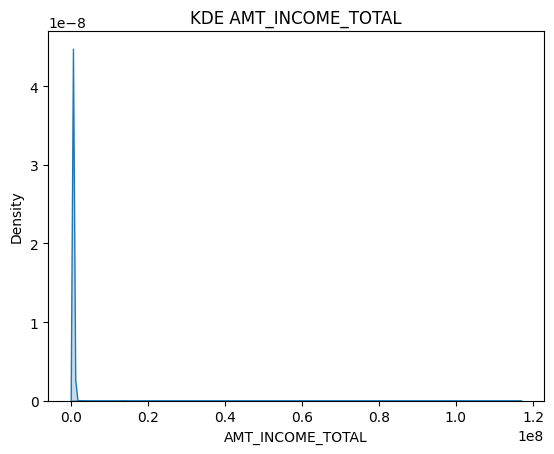

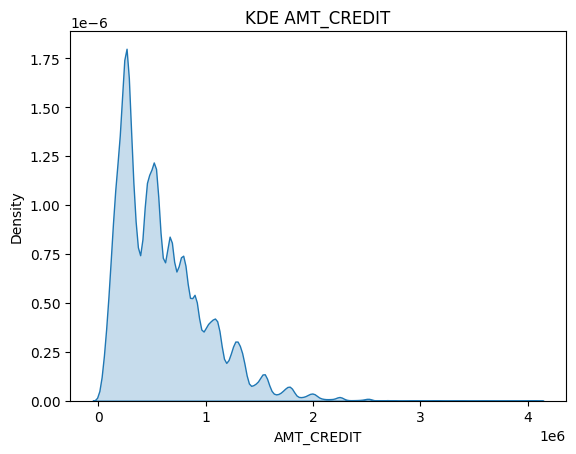

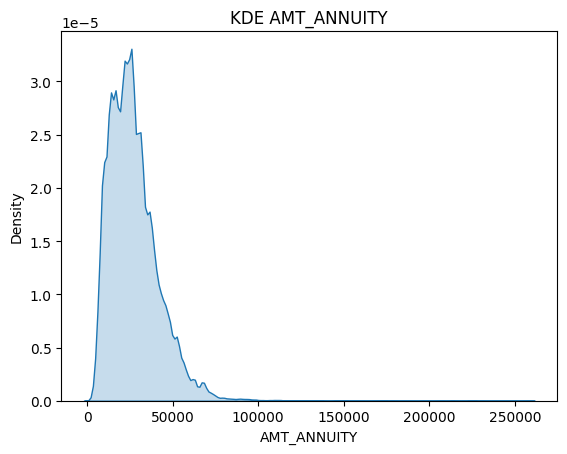

In [34]:
# detecting and teating outliers
import seaborn as sns
import matplotlib.pyplot as plt
reqd_cols = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']
for col in reqd_cols:
  plt.figure()
  sns.kdeplot(data=joined_df,x=col,fill=True)
  plt.title(f'KDE {col}')
  plt.xlabel(col)
  plt.show()

In [35]:
#now let's find skewness
print(joined_df['AMT_INCOME_TOTAL'].skew())
print(joined_df['AMT_CREDIT'].skew())
print(joined_df['AMT_ANNUITY'].skew())

391.5596541041876
1.2347784971349398
1.5797773638612507


All three monetary variables are positively skewed, which is expected in financial data. However, income shows extreme skewness (~391), indicating the presence of significant outliers and the need for transformation or capping. Loan amount and annuity exhibit moderate skewness, which is acceptable and commonly observed in credit datasets

In [36]:
joined_df['LOG_AMT_INCOME'] = np.log1p(joined_df['AMT_INCOME_TOTAL'])
joined_df['LOG_LOAN_AMT'] = np.log1p(joined_df['AMT_CREDIT'])
joined_df['LOG_AMT_ANNUITY'] = np.log1p(joined_df['AMT_ANNUITY'])

In [37]:
print(joined_df['LOG_AMT_INCOME'].skew())
print(joined_df['LOG_LOAN_AMT'].skew())
print(joined_df['LOG_AMT_ANNUITY'].skew())

0.16998210102945838
-0.3388175631376477
-0.34566086309791993


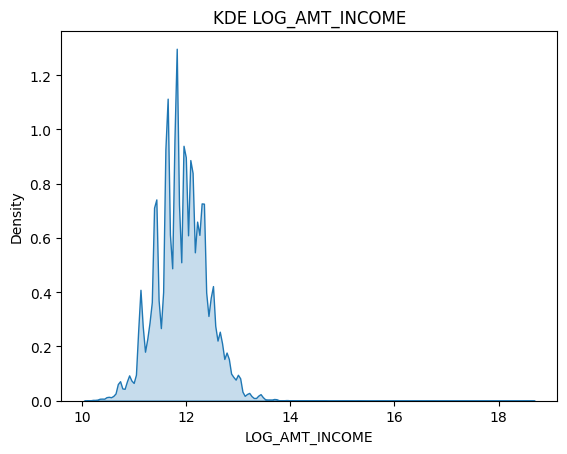

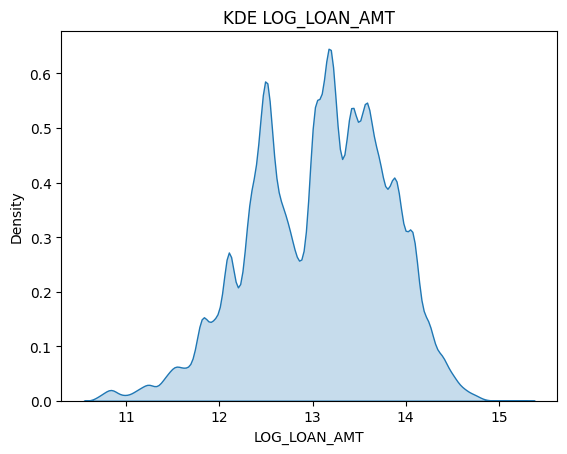

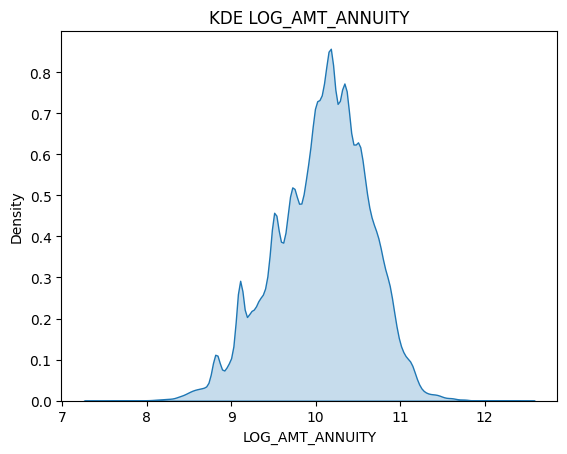

In [38]:
treated_cols = ['LOG_AMT_INCOME','LOG_LOAN_AMT','LOG_AMT_ANNUITY']
for col in treated_cols:
  plt.figure()
  sns.kdeplot(data = joined_df,x=col,fill=True)
  plt.title(f'KDE {col}')
  plt.xlabel(xlabel=col)
  plt.show()

Now the skew is within -0.5 to 0.5 though some spikes can be observed

In [39]:
# univariate analysis
joined_df['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,91.927118
1,8.072882


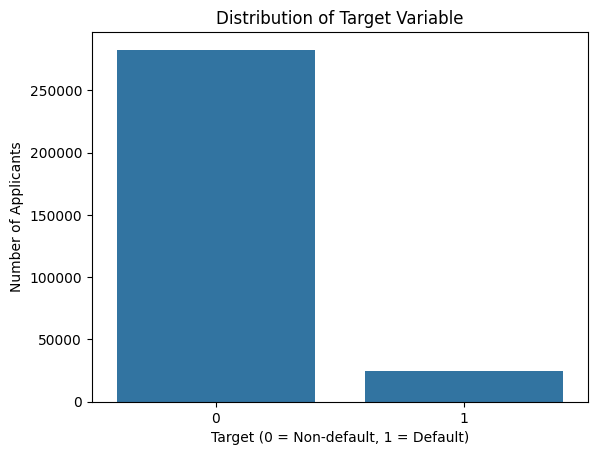

In [40]:
sns.countplot(x='TARGET', data=joined_df)
plt.xlabel('Target (0 = Non-default, 1 = Default)')
plt.ylabel('Number of Applicants')
plt.title('Distribution of Target Variable')
plt.show()

In [41]:
joined_df['DAYS_BIRTH']
joined_df['Age'] = round(-joined_df['DAYS_BIRTH'].round(1)/365)

In [42]:
joined_df['Age']

,Age
0,26.0
1,46.0
2,52.0
3,52.0
4,55.0
...,...
307506,26.0
307507,57.0
307508,41.0
307509,33.0


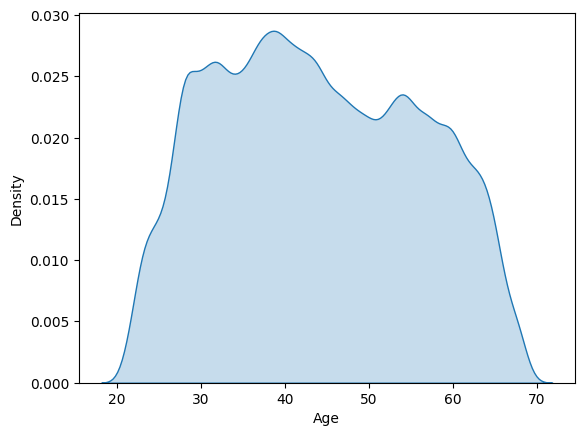

In [43]:
#get age disributuion
plt.figure()
sns.kdeplot(data=joined_df,x='Age',fill=True)
plt.xlabel(xlabel='Age')
plt.show()

In [44]:
joined_df['Age'].skew()

np.float64(0.1151343538689001)

The dutriibutuion is almost normal

In [45]:
joined_df['HAS_PREV_APP'].value_counts(normalize=True) * 100

,proportion
HAS_PREV_APP,
1,94.649297
0,5.350703


<Axes: xlabel='HAS_PREV_APP', ylabel='count'>

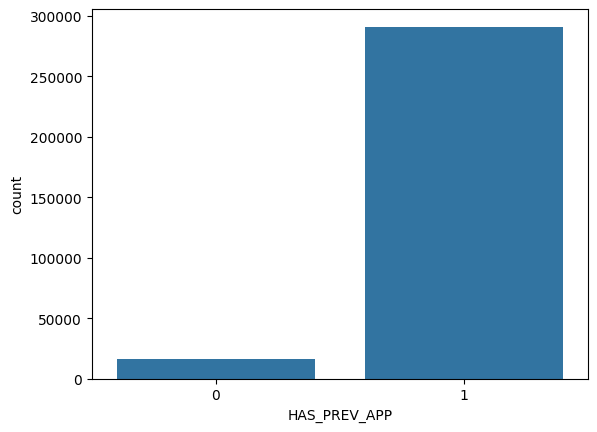

In [46]:
sns.countplot(x='HAS_PREV_APP',data=joined_df)

##Bivariate Analysis

In [47]:
joined_df['NAME_CONTRACT_TYPE'].unique()


array(['Cash loans', 'Revolving loans'], dtype=object)

In [48]:
prev_appl_df['NAME_GOODS_CATEGORY'].unique()

array(['Mobile', 'XNA', 'Consumer Electronics', 'Construction Materials',
       'Auto Accessories', 'Photo / Cinema Equipment', 'Computers',
       'Audio/Video', 'Medicine', 'Clothing and Accessories', 'Furniture',
       'Sport and Leisure', 'Homewares', 'Gardening', 'Jewelry',
       'Vehicles', 'Education', 'Medical Supplies', 'Other',
       'Direct Sales', 'Office Appliances', 'Fitness', 'Tourism',
       'Insurance', 'Additional Service', 'Weapon', 'Animals',
       'House Construction'], dtype=object)

In [49]:
#default rates across categories
reqd = ['Vehicles', 'Education','House Construction','Mobile','Consumer Electronics','Construction Materials','Auto Accessories']
prev_appl_loan_df = prev_appl_df[['SK_ID_PREV','SK_ID_CURR','NAME_GOODS_CATEGORY']].copy()
for _ in reqd:
  prev_appl_loan_df[f'HAS_{_.replace(' ','_')}_LOAN'] = (prev_appl_loan_df["NAME_GOODS_CATEGORY"] == _ ).astype(int)


We will consider only columns that represents home loans, personal loans education loans and vehicle Loans

As the parameter for deafulter is present in the current application and the loan history s present in the previous applications so we are creating sepparate columns for the interested loan categories , then aggreagating them based on **SK_ID_CURR** and then joining with relevant columns in present apllications dataframe

In [50]:
prev_appl_loan_df.columns
has_cols = prev_appl_loan_df.columns[3:]

In [51]:
prev_appl_loan_df.head(20)

,SK_ID_PREV,SK_ID_CURR,NAME_GOODS_CATEGORY,HAS_Vehicles_LOAN,HAS_Education_LOAN,HAS_House_Construction_LOAN,HAS_Mobile_LOAN,HAS_Consumer_Electronics_LOAN,HAS_Construction_Materials_LOAN,HAS_Auto_Accessories_LOAN
0,2030495,271877,Mobile,0,0,0,1,0,0,0
1,2802425,108129,XNA,0,0,0,0,0,0,0
2,2523466,122040,XNA,0,0,0,0,0,0,0
3,2819243,176158,XNA,0,0,0,0,0,0,0
4,1784265,202054,XNA,0,0,0,0,0,0,0
5,1383531,199383,XNA,0,0,0,0,0,0,0
6,2315218,175704,XNA,0,0,0,0,0,0,0
7,1656711,296299,XNA,0,0,0,0,0,0,0
8,2367563,342292,XNA,0,0,0,0,0,0,0
9,2579447,334349,XNA,0,0,0,0,0,0,0


In [52]:
prev_appl_loan_agg_df = prev_appl_loan_df.groupby('SK_ID_CURR')[has_cols].max().reset_index()

In [53]:
prev_appl_loan_agg_df.head(20)

,SK_ID_CURR,HAS_Vehicles_LOAN,HAS_Education_LOAN,HAS_House_Construction_LOAN,HAS_Mobile_LOAN,HAS_Consumer_Electronics_LOAN,HAS_Construction_Materials_LOAN,HAS_Auto_Accessories_LOAN
0,100001,0,0,0,1,0,0,0
1,100002,1,0,0,0,0,0,0
2,100003,0,0,0,0,1,0,0
3,100004,0,0,0,1,0,0,0
4,100005,0,0,0,1,0,0,0
5,100006,0,0,0,0,0,1,0
6,100007,0,0,0,0,0,0,0
7,100008,0,0,0,1,1,0,0
8,100009,0,0,0,1,1,0,0
9,100010,0,0,0,0,0,0,0


In [54]:
appl_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [55]:
def_rate_df = joined_df[['SK_ID_CURR', 'TARGET']].copy()
def_rate_df= pd.merge(def_rate_df,prev_appl_loan_agg_df,on = 'SK_ID_CURR', how ='left' )


In [56]:
def_rate_df[has_cols] = def_rate_df[has_cols].fillna(0)
print(has_cols)

Index(['HAS_Vehicles_LOAN', 'HAS_Education_LOAN',
       'HAS_House_Construction_LOAN', 'HAS_Mobile_LOAN',
       'HAS_Consumer_Electronics_LOAN', 'HAS_Construction_Materials_LOAN',
       'HAS_Auto_Accessories_LOAN'],
      dtype='object')


In [57]:
# now calculating default rates
home_loan_default_rate = (
    def_rate_df
    .groupby('HAS_House_Construction_LOAN')['TARGET']
    .mean()
).reset_index()

constr_loan_default_rate = (
    def_rate_df
    .groupby('HAS_Construction_Materials_LOAN')['TARGET']
    .mean()

).reset_index()

vehicle_loan_default_rate = (
    def_rate_df
    .groupby('HAS_Vehicles_LOAN')['TARGET']
    .mean()
).reset_index()

auto_par_default_rate = (
    def_rate_df
    .groupby('HAS_Auto_Accessories_LOAN')['TARGET']
    .mean()
).reset_index()

mobile_loan_default_rate = (
    def_rate_df.groupby('HAS_Mobile_LOAN')['TARGET']
    .mean()
).reset_index()

cons_elec_loan_default_rate = (
    def_rate_df
    .groupby('HAS_Consumer_Electronics_LOAN')['TARGET']
    .mean()
).reset_index()

edu_loan_default_rate = (
    def_rate_df
    .groupby('HAS_Education_LOAN')['TARGET']
    .mean()
).reset_index()
print(home_loan_default_rate)
print(constr_loan_default_rate)
print(vehicle_loan_default_rate)
print(auto_par_default_rate)
print(mobile_loan_default_rate)
print(cons_elec_loan_default_rate)
print(edu_loan_default_rate)

   HAS_House_Construction_LOAN    TARGET
0                          0.0  0.080729
   HAS_Construction_Materials_LOAN    TARGET
0                              0.0  0.081425
1                              1.0  0.069437
   HAS_Vehicles_LOAN    TARGET
0                0.0  0.080597
1                1.0  0.096288
   HAS_Auto_Accessories_LOAN    TARGET
0                        0.0  0.080574
1                        1.0  0.089510
   HAS_Mobile_LOAN    TARGET
0              0.0  0.077103
1              1.0  0.086099
   HAS_Consumer_Electronics_LOAN    TARGET
0                            0.0  0.083808
1                            1.0  0.071996
   HAS_Education_LOAN    TARGET
0                 0.0  0.080733
1                 1.0  0.063291


In [58]:
home_loan_default_rate['TARGET']

,TARGET
0,0.080729


In [59]:
loan_columns = [ 'HAS_House_Construction_LOAN', 'HAS_Construction_Materials_LOAN', 'HAS_Vehicles_LOAN', 'HAS_Auto_Accessories_LOAN', 'HAS_Mobile_LOAN', 'HAS_Consumer_Electronics_LOAN', 'HAS_Education_LOAN' ]
loan_counts = ( def_rate_df[loan_columns]
               .sum()
.reset_index() )
loan_counts.columns = ['Loan Type','counts']
loan_counts['Loan Type'] = loan_counts['Loan Type'].str.replace('HAS_','',regex=True)
loan_counts['Loan Type'] = loan_counts['Loan Type'].str.replace('_LOAN','',regex=True)
loan_counts

,Loan Type,counts
0,House_Construction,0.0
1,Construction_Materials,17858.0
2,Vehicles,2586.0
3,Auto_Accessories,5329.0
4,Mobile,123951.0
5,Consumer_Electronics,80171.0
6,Education,79.0


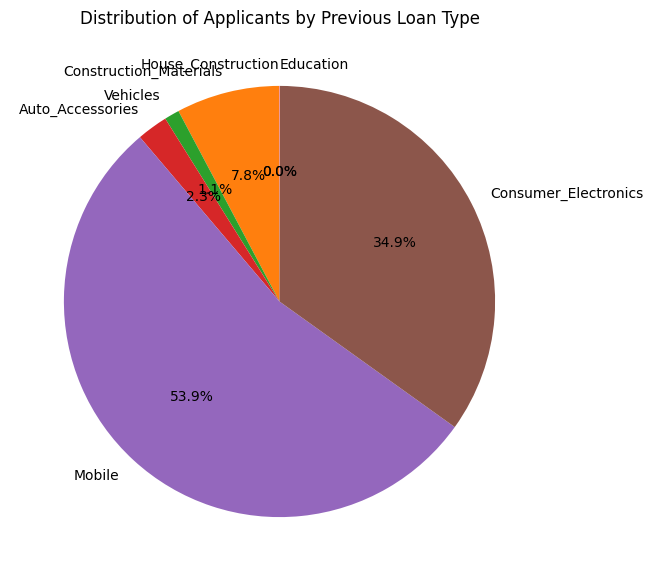

In [60]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))
plt.pie(loan_counts['counts'],labels = loan_counts['Loan Type'],
            autopct='%1.1f%%',
         startangle=90)
plt.title('Distribution of Applicants by Previous Loan Type')
plt.show()

In [61]:
def rate(df, col):

    return df.query(f"{col} == 1")["TARGET"].squeeze()

default_rate_summary = pd.DataFrame({
    "Loan_Type": [
        "House Construction",
        "Construction Materials",
        "Vehicles",
        "Auto Accessories",
        "Mobile",
        "Consumer Electronics",
        "Education"
    ],
    "Default_Rate": [
        rate(home_loan_default_rate, "HAS_House_Construction_LOAN"),
        rate(constr_loan_default_rate, "HAS_Construction_Materials_LOAN"),
        rate(vehicle_loan_default_rate, "HAS_Vehicles_LOAN"),
        rate(auto_par_default_rate, "HAS_Auto_Accessories_LOAN"),
        rate(mobile_loan_default_rate, "HAS_Mobile_LOAN"),
        rate(cons_elec_loan_default_rate, "HAS_Consumer_Electronics_LOAN"),
        rate(edu_loan_default_rate, "HAS_Education_LOAN"),
    ]
})

default_rate_summary


,Loan_Type,Default_Rate
0,House Construction,"Series([], Name: TARGET, dtype: float64)"
1,Construction Materials,0.069437
2,Vehicles,0.096288
3,Auto Accessories,0.08951
4,Mobile,0.086099
5,Consumer Electronics,0.071996
6,Education,0.063291


In [62]:
def fix_default_rate(x):
    if isinstance(x, pd.Series):
        return x.iloc[0] if not x.empty else None
    else:
        return x  # keep scalar as-is

default_rate_summary['Default_Rate'] = default_rate_summary['Default_Rate'].apply(fix_default_rate)
default_rate_summary

,Loan_Type,Default_Rate
0,House Construction,NaN
1,Construction Materials,0.069437
2,Vehicles,0.096288
3,Auto Accessories,0.089510
4,Mobile,0.086099
5,Consumer Electronics,0.071996
6,Education,0.063291


No deafulters for home loan

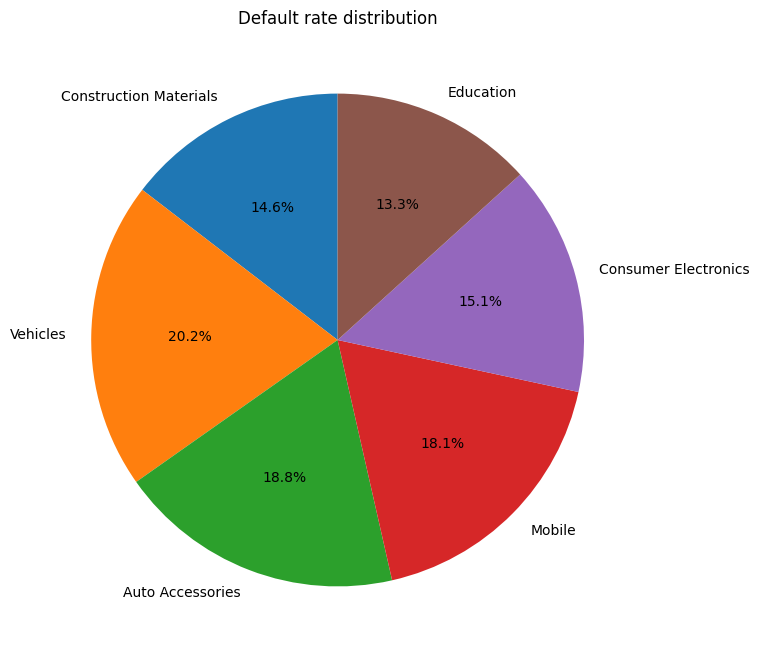

In [63]:
# drppoing the NaN values as
def_plt =default_rate_summary.dropna()
plt.figure(figsize=(8,8))
plt.pie(def_plt['Default_Rate'],labels=def_plt['Loan_Type'],autopct='%1.1f%%',startangle=90)
plt.title('Default rate distribution')
plt.show()

In [64]:
appl_df['ORGANIZATION_TYPE'].unique().tolist()

['Business Entity Type 3',
 'School',
 'Government',
 'Religion',
 'Other',
 'XNA',
 'Electricity',
 'Medicine',
 'Business Entity Type 2',
 'Self-employed',
 'Transport: type 2',
 'Construction',
 'Housing',
 'Kindergarten',
 'Trade: type 7',
 'Industry: type 11',
 'Military',
 'Services',
 'Security Ministries',
 'Transport: type 4',
 'Industry: type 1',
 'Emergency',
 'Security',
 'Trade: type 2',
 'University',
 'Transport: type 3',
 'Police',
 'Business Entity Type 1',
 'Postal',
 'Industry: type 4',
 'Agriculture',
 'Restaurant',
 'Culture',
 'Hotel',
 'Industry: type 7',
 'Trade: type 3',
 'Industry: type 3',
 'Bank',
 'Industry: type 9',
 'Insurance',
 'Trade: type 6',
 'Industry: type 2',
 'Transport: type 1',
 'Industry: type 12',
 'Mobile',
 'Trade: type 1',
 'Industry: type 5',
 'Industry: type 10',
 'Legal Services',
 'Advertising',
 'Trade: type 5',
 'Cleaning',
 'Industry: type 13',
 'Trade: type 4',
 'Telecom',
 'Industry: type 8',
 'Realtor',
 'Industry: type 6']

Let's bucket the categories as there are so many salaried org types

In [65]:
appl_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [66]:
def bucket_org_type(col):
  if col in ['Business Entity Type 1','Business Entity Type 2','Business Entity Type 3']:
    return 'business'
  elif col == 'Self-employed':
    return 'self-employed'
  elif col == None:
    return None
  else:
    return 'salaried'

job_cat_df = appl_df[['SK_ID_CURR','TARGET','ORGANIZATION_TYPE']].copy()
job_cat_df

,SK_ID_CURR,TARGET,ORGANIZATION_TYPE
0,100002,1,Business Entity Type 3
1,100003,0,School
2,100004,0,Government
3,100006,0,Business Entity Type 3
4,100007,0,Religion
...,...,...,...
307506,456251,0,Services
307507,456252,0,XNA
307508,456253,0,School
307509,456254,1,Business Entity Type 1


In [67]:
job_cat_df['JOB_CATEGORY'] = job_cat_df['ORGANIZATION_TYPE'].apply(bucket_org_type)

In [68]:
job_cat_df[job_cat_df['JOB_CATEGORY']== 'self-employed']

,SK_ID_CURR,TARGET,ORGANIZATION_TYPE,JOB_CATEGORY
13,100017,0,Self-employed,self-employed
20,100024,0,Self-employed,self-employed
22,100026,0,Self-employed,self-employed
33,100039,0,Self-employed,self-employed
35,100041,0,Self-employed,self-employed
...,...,...,...,...
307491,456235,0,Self-employed,self-employed
307492,456236,0,Self-employed,self-employed
307494,456238,0,Self-employed,self-employed
307496,456240,0,Self-employed,self-employed


In [69]:
job_def_rate = (
    job_cat_df
    .groupby('JOB_CATEGORY')
    .agg(def_rate = ('TARGET','mean'),
         applicant_count=('TARGET', 'size'))
).reset_index()

In [70]:
job_def_rate

,JOB_CATEGORY,def_rate,applicant_count
0,business,0.091211,84529
1,salaried,0.071556,184570
2,self-employed,0.101739,38412


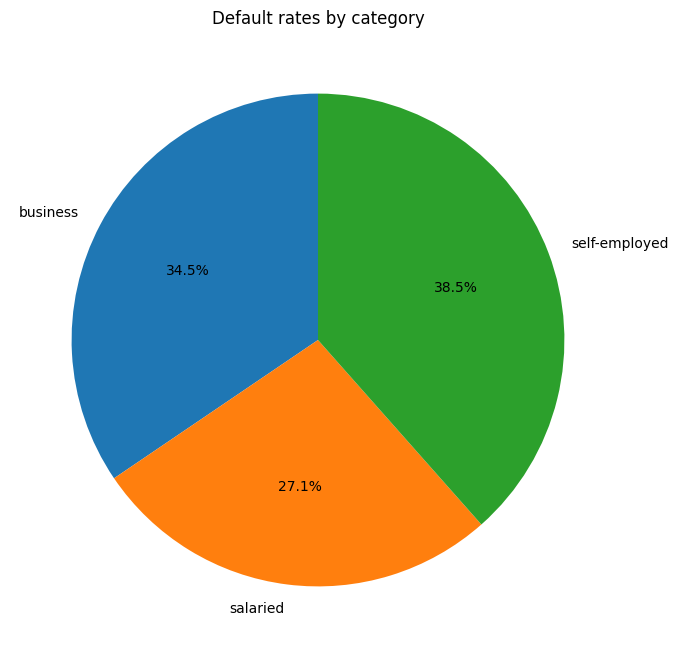

In [71]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.pie(job_def_rate['def_rate'],labels=job_def_rate['JOB_CATEGORY'],autopct="%1.1f%%",startangle=90)
plt.title('Default rates by category')
plt.show()

People who are self employed are defaulted more than the other
job categories

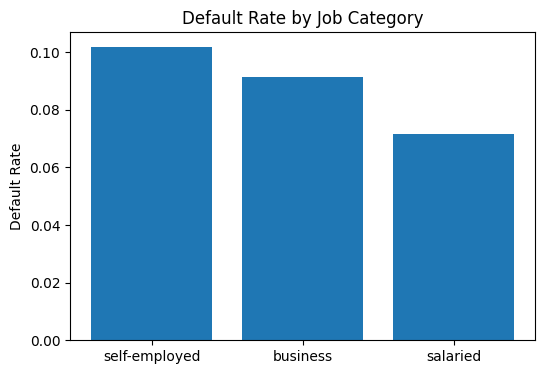

In [72]:
job_def_rate = job_def_rate.sort_values('def_rate', ascending=False)

plt.figure(figsize=(6,4))
plt.bar(job_def_rate['JOB_CATEGORY'], job_def_rate['def_rate'])
plt.ylabel('Default Rate')
plt.title('Default Rate by Job Category')
plt.show()


In [73]:
appl_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [74]:
lti_df =appl_df[['SK_ID_CURR','TARGET','AMT_CREDIT','AMT_INCOME_TOTAL']].copy()
lti_df = lti_df[lti_df['AMT_INCOME_TOTAL'] > 0]


In [75]:
lti_df['LOAN_TO_INCOME_RATIO'] = (
    lti_df['AMT_CREDIT'] / lti_df['AMT_INCOME_TOTAL']
)


In [76]:
lti_df

,SK_ID_CURR,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL,LOAN_TO_INCOME_RATIO
0,100002,1,406597.5,202500.0,2.007889
1,100003,0,1293502.5,270000.0,4.790750
2,100004,0,135000.0,67500.0,2.000000
3,100006,0,312682.5,135000.0,2.316167
4,100007,0,513000.0,121500.0,4.222222
...,...,...,...,...,...
307506,456251,0,254700.0,157500.0,1.617143
307507,456252,0,269550.0,72000.0,3.743750
307508,456253,0,677664.0,153000.0,4.429176
307509,456254,1,370107.0,171000.0,2.164368


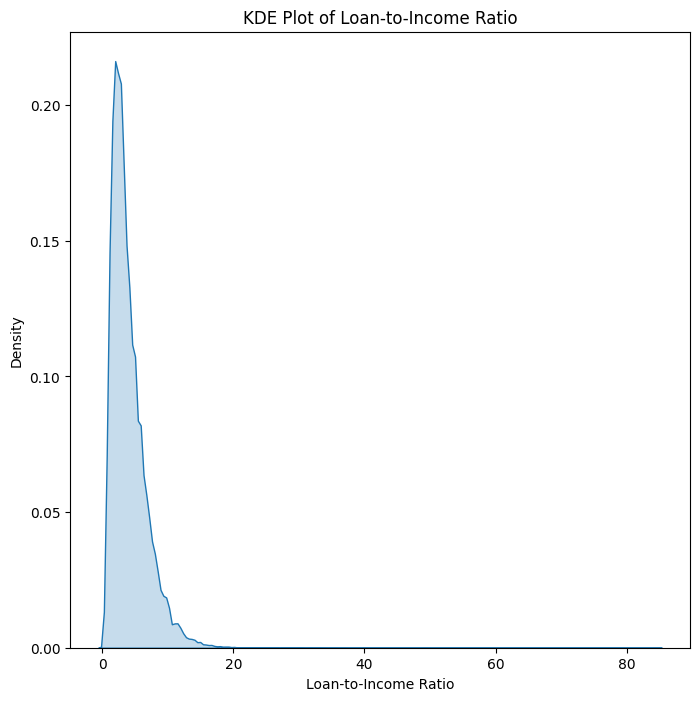

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,8))
sns.kdeplot(data = lti_df,x= "LOAN_TO_INCOME_RATIO",fill =True)
plt.xlabel('Loan-to-Income Ratio')
plt.title('KDE Plot of Loan-to-Income Ratio')
plt.show()

The loan-to-income ratio is heavily right-skewed, indicating that while most applicants have manageable loan burdens, a small fraction exhibit extremely high leverage.”

Now very high values can be clipped

In [78]:
lti_df['LOAN_TO_INCOME_RATIO'] = (
    lti_df['LOAN_TO_INCOME_RATIO'].clip(upper=10)
)


In [79]:
lti_df.count()

,0
SK_ID_CURR,307511
TARGET,307511
AMT_CREDIT,307511
AMT_INCOME_TOTAL,307511
LOAN_TO_INCOME_RATIO,307511


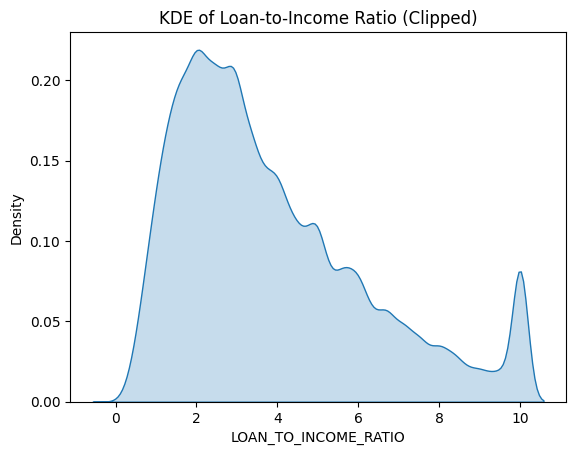

In [80]:
sns.kdeplot(
    data=lti_df,
    x='LOAN_TO_INCOME_RATIO',
    fill=True
)
plt.title('KDE of Loan-to-Income Ratio (Clipped)')
plt.show()


In [81]:
lti_df['LOAN_TO_INCOME_RATIO'].skew()


np.float64(0.9381379959328094)

It is morderately right skewed

In [82]:
lti_df['LTI_BIN'] = pd.qcut(
    lti_df['LOAN_TO_INCOME_RATIO'],
    q=10,
    duplicates = 'drop'
)

In [83]:
lti_df['LTI_BIN'].unique()

[(1.818, 2.266], (4.725, 5.769], (2.266, 2.764], (3.906, 4.725], (7.488, 10.0], (2.764, 3.265], (5.769, 7.488], (3.265, 3.906], (0.00381, 1.332], (1.332, 1.818]]
Categories (10, interval[float64, right]): [(0.00381, 1.332] < (1.332, 1.818] < (1.818, 2.266] <
                                            (2.266, 2.764] ... (3.906, 4.725] < (4.725, 5.769] <
                                            (5.769, 7.488] < (7.488, 10.0]]

In [84]:
lti_default_rate = (
    lti_df
    .groupby('LTI_BIN')['TARGET']
    .mean()
    .reset_index()
)


/tmp/ipython-input-2875391930.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('LTI_BIN')['TARGET']


In [85]:
lti_summary = (
    lti_df.groupby('LTI_BIN')
    .agg(default_rate = ('TARGET','mean'),customer_cnt = ('TARGET','count'))
    .reset_index()
)

/tmp/ipython-input-2130585335.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lti_df.groupby('LTI_BIN')


In [86]:
lti_summary

,LTI_BIN,default_rate,customer_cnt
0,"(0.00381, 1.332]",0.069085,30759
1,"(1.332, 1.818]",0.077615,30780
2,"(1.818, 2.266]",0.081126,30730
3,"(2.266, 2.764]",0.090212,30772
4,"(2.764, 3.265]",0.086542,30725
5,"(3.265, 3.906]",0.091962,30741
6,"(3.906, 4.725]",0.086168,30754
7,"(4.725, 5.769]",0.079510,30751
8,"(5.769, 7.488]",0.074412,30815
9,"(7.488, 10.0]",0.070656,30684


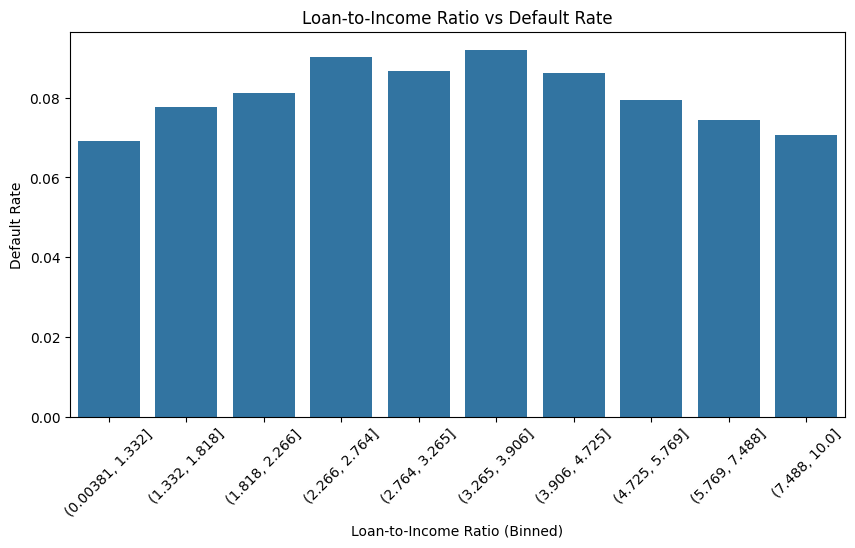

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    data=lti_summary,
    x='LTI_BIN',
    y='default_rate'
)

plt.xticks(rotation=45)
plt.xlabel('Loan-to-Income Ratio (Binned)')
plt.ylabel('Default Rate')
plt.title('Loan-to-Income Ratio vs Default Rate')

plt.show()
